In [ ]:
# Generating dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lukechugh/best-alzheimer-mri-dataset-99-accuracy")

print("Path to dataset files:", path)

100%|██████████| 71.5M/71.5M [00:00<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lukechugh/best-alzheimer-mri-dataset-99-accuracy/versions/1


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 11519 files belonging to 2 classes.
['test', 'train']
--- Loading Data ---
Found 10240 files belonging to 4 classes.
Found 1279 files belonging to 4 classes.
Class Names: ['Mild Impairment', 'Moderate Impairment', 'No Impairment', 'Very Mild Impairment']
Class Counts (Train): {np.int32(1): 2560, np.int32(3): 2560, np.int32(2): 2560, np.int32(0): 2560}
--- Building Functional Model ---


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 224, 224,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc

 Total params: 20,141,095 (76.83 MB)

 Trainable params: 19,750,284 (75.34 MB)

 Non-trainable params: 390,811 (1.49 MB)

--- Starting Model Training ---
Epoch 1/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 91s 203ms/step - accuracy: 0.6993 - loss: 1.6270 - val_accuracy: 0.6654 - val_loss: 1.3401 - learning_rate: 0.0010
Epoch 2/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 62s 195ms/step - accuracy: 0.8015 - loss: 0.9351 - val_accuracy: 0.6380 - val_loss: 1.2388 - learning_rate: 0.0010
Epoch 3/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 62s 194ms/step - accuracy: 0.8352 - loss: 0.7033 - val_accuracy: 0.7498 - val_loss: 0.8927 - learning_rate: 0.0010
Epoch 4/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 62s 192ms/step - accuracy: 0.8674 - loss: 0.5677 - val_accuracy: 0.7639 - val_loss: 0.7961 - learning_rate: 0.0010
Epoch 5/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 62s 194ms/step - accuracy: 0.8896 - loss: 0.4673 - val_accuracy: 0.7404 - val_loss: 0.7778 - learning_rate: 0.0010
Epoch 6/59
320/320 ━━━━━━━━━━━━━━━━━━━━ 68s 213ms/step - accuracy: 0.9089 - loss: 0.3904 - val_accuracy: 0.8194 - val_loss: 0.5517 - learning_rate: 0.0010
Epoch 7/59
320/320 ━━━━━━━━━━━━━━━━━━━

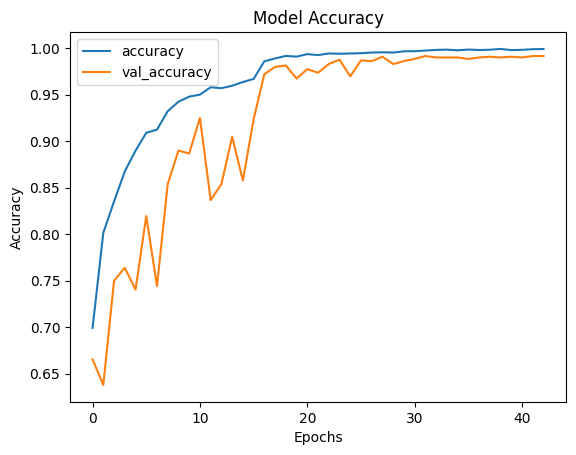

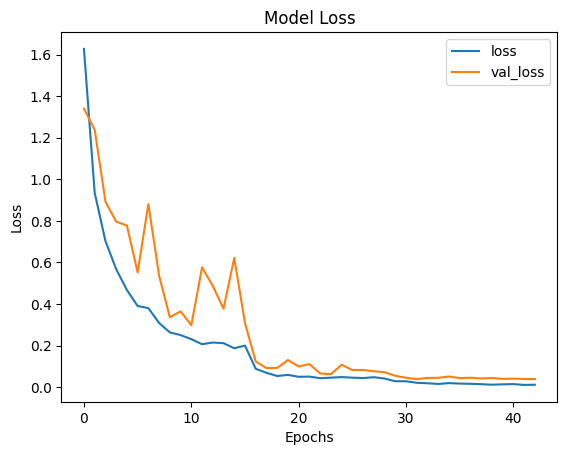


--- Generating Predictions and Classification Report ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━

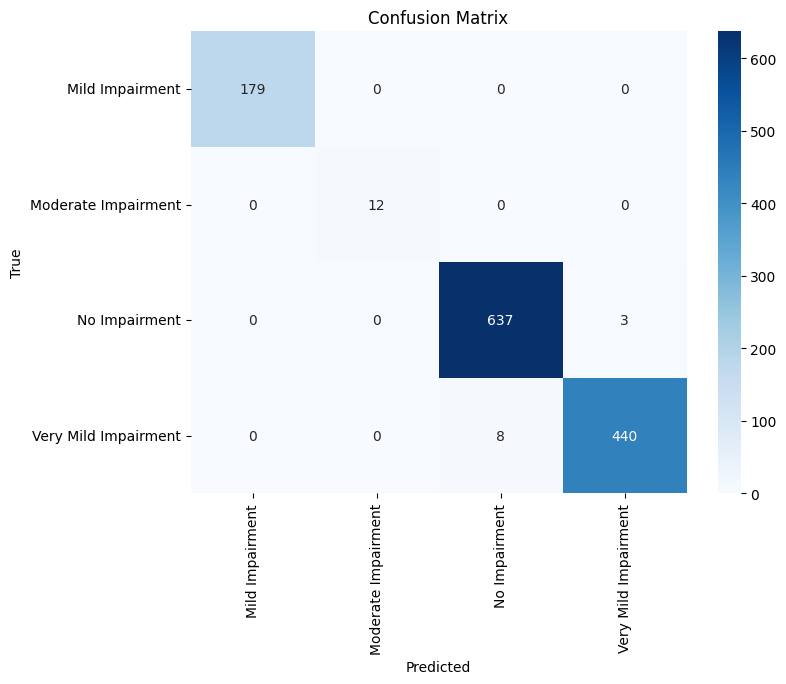


--- Generating AUC-ROC Curve ---


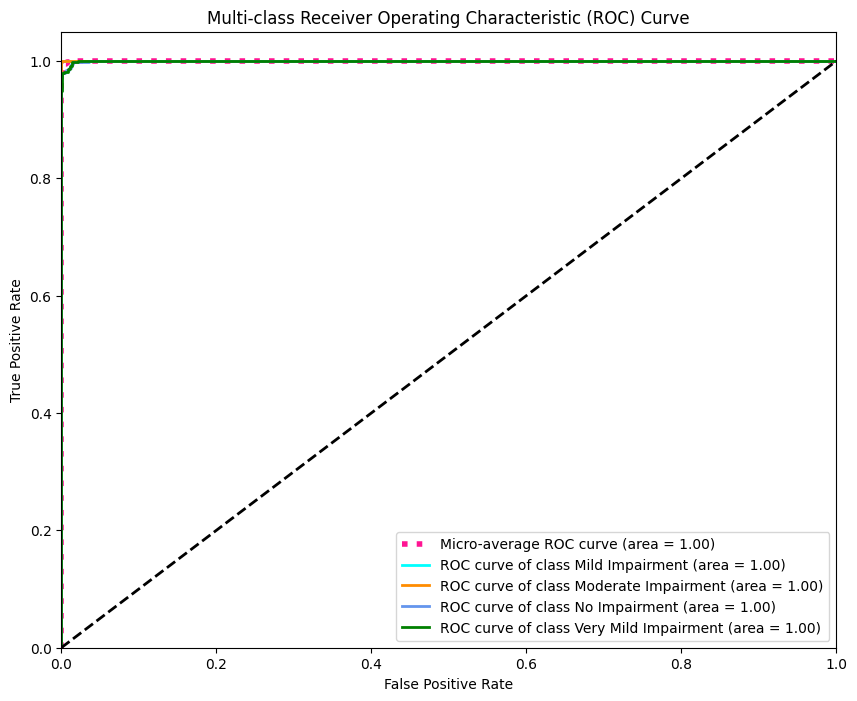

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import (
    Dense, Flatten, RandomFlip, RandomRotation, Input,
    BatchNormalization, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
from collections import Counter

# --- NEW: Imports for ROC Curve ---
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
# -----------------------------------

from google.colab import drive
drive.mount('/content/drive')

dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/Shareddrives/Al_Meu/CombinedDataset",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

class_names = dataset.class_names
print(class_names)
# --- 0. Configuration ---
DATA_DIR = '/content/drive/Shareddrives/Al_Meu/CombinedDataset'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')
SAVE_MODEL_PATH = '/content/drive/Shareddrives/Al_Meu/CombinedDataset/alzheimers_efficientnet_model1.keras'
NUM_CLASSES = 4 # We have 4 classes

# --- 1. Load Data ---
print("--- Loading Data ---")
train_dataset = keras.utils.image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='int', # Labels are integers (0, 1, 2, 3)
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    verbose=True
)

test_dataset = keras.utils.image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(224, 224),
    shuffle=False, # Must be False for evaluation
    verbose=True
)

class_name = train_dataset.class_names
print(f"Class Names: {class_name}")
class_counts = Counter()
for _, labels in train_dataset:
    class_counts.update(labels.numpy())
print(f"Class Counts (Train): {dict(class_counts)}")

# --- 2. Preprocessing ---
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

data = train_dataset.map(preprocess)
test = test_dataset.map(preprocess)

# --- 3. Build Model with Functional API ---
print("--- Building Functional Model ---")

inputs = Input(shape=(224, 224, 3))
x = RandomFlip("horizontal")(inputs)
x = RandomRotation(0.1)(x)

transmodel = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=x
)

transmodel.trainable = True
set_trainable = False
for layer in transmodel.layers:
    if layer.name == 'block5a_expand_activation':
        set_trainable = True
    layer.trainable = set_trainable

x = transmodel.output
x = Flatten()(x)
x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# --- 4. Define Callbacks ---
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.01,
    patience=11,
    verbose=1,
    mode="auto",
    restore_best_weights=True,
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# --- 5. Compile the Model ---
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# --- 6. Train the Model ---
print("--- Starting Model Training ---")
history = model.fit(
    data,
    batch_size=32,
    epochs=59,
    validation_data=test,
    callbacks=[callback, lr_scheduler]
)

# --- 7. Save the Model ---
print(f"\n--- Saving model to {SAVE_MODEL_PATH} ---")
model.save(SAVE_MODEL_PATH)
print("Model saved successfully. You can now download it.")

# --- 8. Evaluate Model ---
print("\n--- Model Evaluation ---")
loss, accuracy = model.evaluate(test)
print(f"Test Accuracy: {accuracy * 100:.2f}%") # This will show your 99.30%
print(f"Test Loss: {loss:.4f}")

# Plot history
print("\n--- Plotting Training History ---")
ef = pd.DataFrame(history.history)
ef[['accuracy','val_accuracy']].plot()
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

ef[['loss','val_loss']].plot()
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# --- 9. Detailed Analysis (Predictions, Report, Matrix) ---
# --- MODIFIED: To get probabilities for ROC curve ---
print("\n--- Generating Predictions and Classification Report ---")

y_true_labels = []      # For integer labels (e.g., 0, 1, 2, 3)
y_pred_labels = []      # For predicted integer labels
y_pred_probs = []       # For predicted probabilities (for ROC)

for images, labels in test:
    y_true_labels.extend(labels.numpy())
    pred = model.predict(images)
    y_pred_probs.append(pred)
    y_pred_labels.extend(np.argmax(pred, axis=1))

# Concatenate all batches of probabilities
y_pred_probs = np.concatenate(y_pred_probs, axis=0)

# Binarize the true labels for ROC curve calculation
y_true_one_hot = label_binarize(y_true_labels, classes=range(NUM_CLASSES))

# Classification Report
print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_name))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_name,
            yticklabels=class_name)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# --- 10. NEW: AUC-ROC Curve Plot ---
print("\n--- Generating AUC-ROC Curve ---")

# Set up plot
plt.figure(figsize=(10, 8))

# Dictionaries to store ROC data
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calculate the micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_one_hot.ravel(), y_pred_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot the micro-average ROC curve
plt.plot(fpr["micro"], tpr["micro"],
         label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

# Plot ROC curve for each class (One-vs-Rest)
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green'])
for i, color in zip(range(NUM_CLASSES), colors):
    fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_name[i]} (area = {roc_auc[i]:.2f})')

# Plot the "no-skill" line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Add labels, title, and legend
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [ ]:
import zipfile
from google.colab import drive


drive.mount("/content/drive")

zip_path = "/content/drive/Shareddrives/Al_Meu/CombinedDataset/alzheimers_efficientnet_modelnew.keras"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    print(zip_ref.namelist())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['metadata.json', 'config.json', 'model.weights.h5']


In [ ]:
import zipfile
import os

zip_path = "/content/drive/Shareddrives/Al_Meu/CombinedDataset/alzheimers_efficientnet_modelnew.keras"
extract_path = "/content/drive/Shareddrives/Al_Meu/CombinedDataset/"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Model extracted.")

Model extracted.


In [ ]:
!pip install -q tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 1.9 MB/s eta 0:00:00


BUN


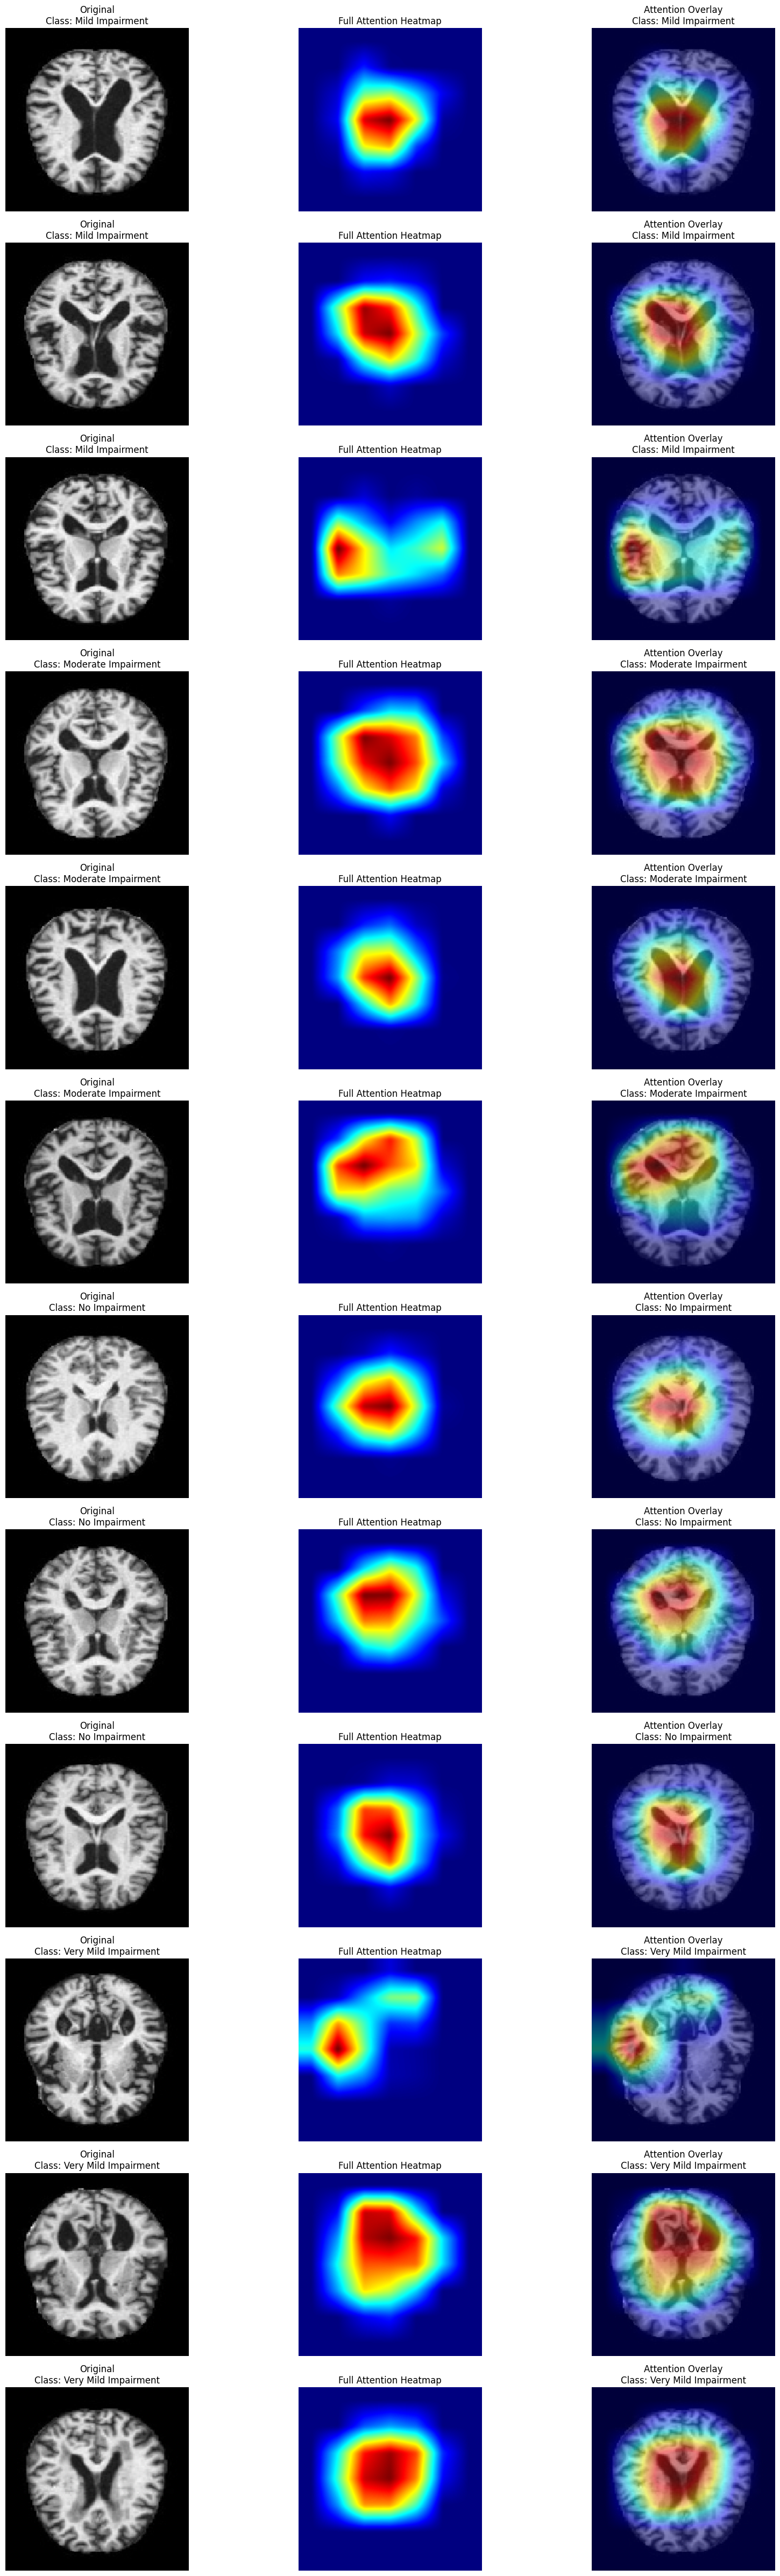

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import glob
import random

MODEL_PATH = "/content/drive/Shareddrives/Al_Meu/CombinedDataset/alzheimers_efficientnet_modelnew.keras"
TEST_DIR = "/content/drive/Shareddrives/Al_Meu/CombinedDataset/test"

IMG_SIZE = (224, 224)
IMAGES_PER_CLASS = 3

model = tf.keras.models.load_model(MODEL_PATH)

class_names = sorted([
    d for d in os.listdir(TEST_DIR)
    if os.path.isdir(os.path.join(TEST_DIR, d))
])

last_conv_layer_name = None

for layer in reversed(model.layers):
    try:
        if len(layer.output.shape) == 4:
            last_conv_layer_name = layer.name
            break
    except:
        pass

feature_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=model.get_layer(last_conv_layer_name).output
)

def load_image(path):
    img = tf.keras.utils.load_img(path, target_size=IMG_SIZE)
    img = tf.keras.utils.img_to_array(img).astype(np.float32)
    return np.expand_dims(img, axis=0), img.astype(np.uint8)

def eigen_attention_map(img_array):
    features = feature_model(img_array)[0].numpy()
    features = np.maximum(features, 0)

    h, w, c = features.shape
    reshaped = features.reshape((-1, c))
    reshaped = reshaped - reshaped.mean(axis=0)

    _, _, vt = np.linalg.svd(reshaped, full_matrices=False)

    cam = reshaped @ vt[0]
    cam = cam.reshape(h, w)

    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, IMG_SIZE)
    cam = cv2.GaussianBlur(cam, (9, 9), 0)
    cam = cam / (cam.max() + 1e-8)

    return cam

def full_heatmap_overlay(image, cam):
    cam_uint8 = np.uint8(255 * cam)

    heatmap = cv2.applyColorMap(cam_uint8, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(
        image,
        0.55,
        heatmap,
        0.45,
        0
    )

    return heatmap, overlay

selected_images = []

for class_name in class_names:
    image_files = (
        glob.glob(os.path.join(TEST_DIR, class_name, "*.jpg")) +
        glob.glob(os.path.join(TEST_DIR, class_name, "*.jpeg")) +
        glob.glob(os.path.join(TEST_DIR, class_name, "*.png"))
    )

    chosen = random.sample(
        image_files,
        min(IMAGES_PER_CLASS, len(image_files))
    )

    for path in chosen:
        selected_images.append((path, class_name))

rows = len(selected_images)

plt.figure(figsize=(18, rows * 4))

for idx, (img_path, true_class) in enumerate(selected_images):

    img_array, img = load_image(img_path)

    cam = eigen_attention_map(img_array)
    heatmap, overlay = full_heatmap_overlay(img, cam)

    plt.subplot(rows, 3, idx * 3 + 1)
    plt.imshow(img)
    plt.title(f"Original\nClass: {true_class}")
    plt.axis("off")

    plt.subplot(rows, 3, idx * 3 + 2)
    plt.imshow(heatmap)
    plt.title("Full Attention Heatmap")
    plt.axis("off")

    plt.subplot(rows, 3, idx * 3 + 3)
    plt.imshow(overlay)
    plt.title(f"Attention Overlay\nClass: {true_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()